In [1]:
import openfermion as of
from openfermion import QubitOperator

import sys
sys.path.append('../utils/')
import numpy as np
import scipy.io as spio
from matplotlib import pyplot as plt
from linblad_utils import (get_zeeman_mats,
                           get_coords,
                           symmetrize_dipolar_ham,
                           symmetrize_zeeman_coups,
                           integrate_double_commutator,
                           Sp)


from analytical_fit import Get_K2RatesAndOps, Get_K1RatesAndOps, Get_K0RatesAndOps
from basis_utils import Sx,Sy,Sz,build_list_ISTs, read_spinach_info

from ham_comp_utils import generate_heisenberg_hamiltonian

from scipy import sparse
from scipy.linalg import expm 

# Usage example and verification

In [2]:
#####Our starting point is loading data from the parsed Gaussian log file to Spinach...
filename =  '../data/eb_turnoff_deut/inter_dft.mat'
loadMat = spio.loadmat(filename,squeeze_me=True)

#coords = loadMat['spin_system']['inter'].item()['coordinates'].item()
###identifying the target nuclei through their corresponding indexes:
tar_idxs = np.array([11,8,19,10,20,18,12,13])-1 #This list identifies the isotopes: ['1H','13C','19F','2H','2H','1H','2H','2H']

zeeman_mats = np.array(get_zeeman_mats(filename,tar_idxs))
coords = get_coords(filename,tar_idxs)
coords = coords*1e-10 #To change to Armstrongs

####List of gyromagnetic ratios, TODO: need to figure out where we can get access to these values in Spinach
gyro_rats = np.array([42.57747851783256,10.70839657126110,40.07757016369701,6.535901313156391,6.535901313156391,42.57747851783256,6.535901313156391,6.535901313156391])*1e6  #in Hz/T
#B_vec = np.array([0,0,1])

###first magnetic field strength...We need to use parameters up to ~10 significant digits!!!
B0 = 4.6973190279#2*np.pi*1e6*200/2.6752e+08 
B_vec = np.array([0.0,0.0,1.0])*B0
tc = 30e-9 #correlation time in seconds


###Getting isotropic and anisotropic parts of the Hamiltonian, separated according to rotational symmetries

###For simplicity and using physical intuition, we expect deuterons to be irrelevant in the transversal relaxation of the target
#\deltaH, we remove deuterons from the computation...
mask = np.array([0,1,2,5])

iso_zeeman,Q_pqs_zeeman,zeeman_anis= symmetrize_zeeman_coups(zeeman_mats[mask],B_vec,gyro_rats[mask],verbose=True)

Q_pqs_dipolar =symmetrize_dipolar_ham(coords[mask],gyro_rats[mask],verbose=True)


###Generate global dictionary of Qpq operators...
glob_Qpq = {}
Qps_dip_only = {}
for i in range(-2,3):
    for j in range(-2,3):
        glob_Qpq[(i,j)] = 2*np.pi*Q_pqs_zeeman[(i,j)].toarray()+4*np.pi*Q_pqs_dipolar[(i,j)].toarray() ####TODO: something that is still puzzling is the scaling of the dipolar and zeeman anisotropies
                                                                                                        #by these factors...
        Qps_dip_only[(i,j)] = Q_pqs_dipolar[(i,j)].toarray()

Test_op = of.get_sparse_operator(Sp(0),n_qubits=len(mask))
Test_op = np.sqrt((1.0/np.trace(np.conjugate(Test_op).T.toarray()@Test_op.toarray())))*Test_op


trans_rate = integrate_double_commutator(Test_op.toarray(), Test_op.toarray(), 2*np.pi*iso_zeeman.toarray(), glob_Qpq, tc)


Isotropic part of the Zeeman tensor for spin  0
-200001853.1484851*S_z
Anisotropic part of the Zeeman tensor for spin  0
(-329.85000000299885-0.010000000000089816j)*-0.5*S_plus
sanity check diff: 0.0
(-662.5298206433267-0j)*sqrt(2/3)*Sz
(329.85000000299885-0.010000000000089816j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  1
-50309668.60495675*S_z
Anisotropic part of the Zeeman tensor for spin  1
(2698.2280681584825-261.2621213270813j)*-0.5*S_plus
sanity check diff: 0.0
(3040.7739715618354+0j)*sqrt(2/3)*Sz
(-2698.2280681584825-261.2621213270813j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  2
-188238378.98480862*S_z
Anisotropic part of the Zeeman tensor for spin  2
(4402.948411921483+3315.5093221678844j)*-0.5*S_plus
sanity check diff: 0.0
(12462.090283586056+0j)*sqrt(2/3)*Sz
(-4402.948411921483+3315.5093221678844j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  3
-200001870.50848508*S_z
Anisotropic part of the Zeeman tensor for spin  3
(32.700000000

In [7]:
filename= '../data/eb_turnoff_deut/iso_ham.mat'
filename_aniso= '../data/eb_turnoff_deut/aniso_ham.mat'
filename_sumQs = '../data/eb_turnoff_deut/sumQs.mat'
filename_totH = '../data/eb_turnoff_deut/totHam.mat'

filename_eb_deut = '../data/eb_deut/eb_deut_rel_dH.txt'
filename_eb_deut_lev4 = '../data/eb_deut/eb_deut_rel_dH_baslev_4.txt'

filename_to_deuts = '../data/eb_turnoff_deut/eb_deut_rel_dH_baslev_3.txt'


data_eb_deut = np.loadtxt(filename_eb_deut)
data_eb_deut_lev4 = np.loadtxt(filename_eb_deut_lev4)
data_to_deuts = np.loadtxt(filename_to_deuts)




load_isoham = spio.loadmat(filename,squeeze_me=True)
load_anisoham = spio.loadmat(filename_aniso,squeeze_me=True)
load_sumQs = spio.loadmat(filename_sumQs,squeeze_me=True)
load_totH= spio.loadmat(filename_totH,squeeze_me=True)

In [8]:
B_values = [200, 250, 300, 350, 400, 450, 500, 550, 600,
            650, 700, 750, 800, 850, 900, 950, 1000]

B0_list = np.array([2*np.pi*1e6*B/2.6752e+08 for B in B_values])

all_rates = []

for i in range(len(B0_list)):

    B_vec = np.array([0,0,1])*B0_list[i]

    ###Getting isotropic and anisotropic parts of the Hamiltonian, separated according to rotational symmetries
    iso_zeeman,Q_pqs_zeeman,anis_zeem= symmetrize_zeeman_coups(zeeman_mats[mask],B_vec,gyro_rats[mask])

    glob_Qpq = {}
    Qps_dip_only = {}
    for i in range(-2,3):
        for j in range(-2,3):
            glob_Qpq[(i,j)] = 2*np.pi*Q_pqs_zeeman[(i,j)].toarray()+4*np.pi*Q_pqs_dipolar[(i,j)].toarray()
    
    trans_rate = integrate_double_commutator(Test_op.toarray(), Test_op.toarray(), 2*np.pi*iso_zeeman.toarray(), glob_Qpq, tc)

    all_rates.append(trans_rate)

/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


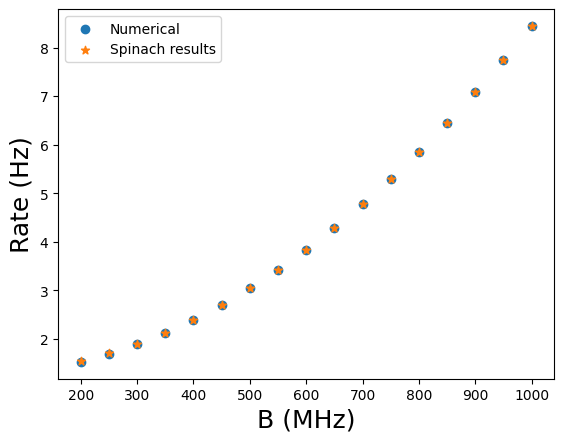

In [9]:
plt.scatter(B_values,-np.array(all_rates),label='Numerical')
plt.scatter(B_values,data_to_deuts[:,1],marker="*",label='Spinach results')
plt.xlabel('B (MHz)',fontsize=18)
plt.ylabel('Rate (Hz)',fontsize=18)
plt.legend()

# Linbladian for a target system

In [3]:
from basis_utils import read_spinach_info, NormalizeBasis
from linblad_utils import comm


from nmr_spec_utils import apodize_exp1d
import re

In [4]:
####Functions in construction...

def integrate_Qs(H0, Qs, tc, qm_keys=None, tol=1e-8):
    """
    Returns Integral_0^∞ e^{-tau/tc} e^{-iH0 tau} Q^† e^{iH0 tau} for all Q basis tensors Qs
    """

    H0 = np.asarray(H0, dtype=complex)
    N = H0.shape[0]
    
    # prepare list of Q operators in canonical order if dict provided
    # canonical key order: (k,m) with k,m in [-2,-1,0,1,2] (sorted)
    if isinstance(Qs, dict):
        ordered_keys = [(k, m) for k in [-2, -1, 0, 1, 2] for m in [-2, -1, 0, 1, 2]]
        Q_list = [np.asarray(Qs[(k, m)], dtype=complex) for (k, m) in ordered_keys]
    else:
        Q_list = list(Qs)
        if len(Q_list) != 25:
            raise ValueError("If Qs is a list/array it must contain 25 operators (for k,m = -2..2).")
        # if user provided qm_keys, we don't change order; otherwise assume the list order is desired.

    # --- diagonalize H0 (assume Hermitian) ---
    # Use eigh for Hermitian matrices (stable, returns real eigenvalues)
    E, V = np.linalg.eigh(2*np.pi*H0)         # H0 = V diag(E) V^†
    # V: columns are eigenvectors. For non-Hermitian H0, one would need general eig.

    # precompute frequency differences omega_ab = E[a] - E[b]
    # we will need denominator 1/tc + i * omega_ab for each element
    E = E.reshape((-1,))             # shape (N,)
    omega = E[:, None] - E[None, :]  # shape (N,N)  (omega_ab)

    # compute kernel factor F_ab = ∫_0^∞ e^{-τ/tc} e^{-i ω_ab τ} dτ = 1/(1/tc + i ω_ab)
    denom = 1.0 / tc + 1j * omega
    # avoid division by extremely small numbers numerically:
    denom[np.abs(denom) < tol] = tol
    F = 1.0 / denom  
    F= np.real(F)                 # shape (N,N), complex

    # compute contribution for each Q
    total = 0.0 + 0.0j

    # for each Q: compute Qd_eig = V^† Q^† V (matrix in eigenbasis), multiply elementwise by F,
    # transform back to lab basis -> Qd_integrated, then form double commutator [Q, [Qd_int, O2]]
    # and accumulate Tr{ O1^† * that }.
    V_dag = V.conj().T

    int_Qs = {}

    counter = 0
    for Q in Q_list:
        Q = np.asarray(Q, dtype=complex)
        # Q_dag in lab basis
        Qdag = Q.conj().T

        # transform Qdag to eigenbasis of H0
        Qdag_eig = V_dag @ Qdag @ V   # shape (N,N)

        # elementwise multiply by F to perform the time integral
        Qdag_int_eig = Qdag_eig * F   # broadcasting elementwise multiplication

        # transform back to lab basis
        Qdag_int = V @ Qdag_int_eig @ V_dag
        int_Qs[ordered_keys[counter]] = Qdag_int
        counter+=1

        

    return int_Qs

###auxiliary function to build the relaxation superoperator in matrix form...
def Innpprod_doublecomm(O1,Qs1,Qs2,O2):
    """
    Returns Tr{O1^dagger [Qs1,[Qs2,O2]]} 
    """

    O1 = np.asarray(O1, dtype=complex)
    O2 = np.asarray(O2, dtype=complex)

    return np.trace(O1.conj().T@comm(Qs1,comm(Qs2,O2)))

def get_isotropic_R(H0,Qs,tc,basis,nqubs=4):

    if isinstance(Qs, dict):
        ordered_keys = [(k, m) for k in [-2, -1, 0, 1, 2] for m in [-2, -1, 0, 1, 2]]
        Q_list = [np.asarray(Qs[(k, m)], dtype=complex) for (k, m) in ordered_keys]
    else:
        Q_list = list(Qs)
        if len(Q_list) != 25:
            raise ValueError("If Qs is a list/array it must contain 25 operators (for k,m = -2..2).")

    intQsdict = integrate_Qs(H0, Qs, tc, qm_keys=None, tol=1e-8)

    Nbasis = len(basis)

    matRep = np.zeros([Nbasis,Nbasis],dtype=complex)

    

    Totels = Nbasis**2
    counter = 0
    report_thresh = np.floor(0.1*Totels)
    thresh_reached = 1

    for i in range(Nbasis):
        basis_i = of.get_sparse_operator(basis[i],n_qubits=nqubs)
        for j in range(Nbasis):
            basis_j = of.get_sparse_operator(basis[j],n_qubits=nqubs)
            
            for key in ordered_keys:
            
                

                matRep[i,j] += Innpprod_doublecomm(basis_j.toarray(),Qs[key],intQsdict[key],basis_i.toarray())

            counter+=1
            if np.floor(counter/report_thresh) >= thresh_reached:
                print("Finsihed:" ,10*thresh_reached, "%")
                thresh_reached+=1


    return matRep  

def singcomm_supOp(Op,basis,nqubs=4):

    Nbasis = len(basis)

    commOp = np.zeros([Nbasis,Nbasis],dtype=complex)

    for i in range(Nbasis):
        basis_i = of.get_sparse_operator(basis[i],n_qubits=nqubs)
        for j in range(Nbasis):
            basis_j = of.get_sparse_operator(basis[j],n_qubits=nqubs)
            commOp[i,j] = np.trace(basis_i.toarray().conj().T@comm(Op,basis_j.toarray()))

    return commOp

###To track the growth in Hamming weight of Pauli products during evolution...

def count_nonzero_tuples(text):
    """
    Given a multiline string where each line contains tuples like (a,b),
    return a list where each entry is the number of tuples in that line
    that are not equal to (0,0).
    """
    lines = text.strip().splitlines()
    counts = []

    for line in lines:
        # extract all tuples (x,y)
        tuples = re.findall(r'\((-?\d+),\s*(-?\d+)\)', line)

        # count tuples not equal to (0,0)
        non_zero = sum(1 for x, y in tuples if not (x == '0' and y == '0'))
        counts.append(non_zero)

    return counts


#####
def get_ham_weights(rho,weight_encods,thresh=1e-5):

    N = len(rho)
    list_hamws=[]
    basis_idxs = []
    for i in range(N):
        if np.abs(rho[i])>= thresh:
            list_hamws.append(weight_encods[i])
            basis_idxs.append(i)

    return np.array(list_hamws),basis_idxs







In [12]:
from rdkit import Chem
from rdkit.Chem import Draw

mol = Chem.MolFromMolFile("../data/eb_turnoff_deut/phe.mol")
Chem.rdDepictor.Compute2DCoords(mol)
img = Draw.MolToImage(mol, size=(400, 300))
img.show()

The application /System/Applications/Preview.app cannot be opened for an unexpected reason, error=Error Domain=NSOSStatusErrorDomain Code=-10673 "(null)" UserInfo={_LSLine=4129, _LSFunction=_LSOpenStuffCallLocal}


In [13]:
img.save("../figures/prefluo_2d.png")

In [5]:
#For simplicity lets assume that the ortho 1H protons were protonated, dipolar relaxation and (pressumably) J couplings to the 13C are negligible
#We only consider 19F, 13C and the 2 "meta" 1H hydrogens...
#TODO: andjust the magnetic field B0

text = """1      (0,0)   (0,0)   (0,0)   (0,0)   
2      (0,0)   (0,0)   (0,0)   (1,1)   
3      (0,0)   (0,0)   (0,0)   (1,0)   
4      (0,0)   (0,0)   (0,0)   (1,-1)  
5      (0,0)   (0,0)   (1,1)   (0,0)   
6      (0,0)   (0,0)   (1,1)   (1,1)   
7      (0,0)   (0,0)   (1,1)   (1,0)   
8      (0,0)   (0,0)   (1,1)   (1,-1)  
9      (0,0)   (0,0)   (1,0)   (0,0)   
10     (0,0)   (0,0)   (1,0)   (1,1)   
11     (0,0)   (0,0)   (1,0)   (1,0)   
12     (0,0)   (0,0)   (1,0)   (1,-1)  
13     (0,0)   (0,0)   (1,-1)  (0,0)   
14     (0,0)   (0,0)   (1,-1)  (1,1)   
15     (0,0)   (0,0)   (1,-1)  (1,0)   
16     (0,0)   (0,0)   (1,-1)  (1,-1)  
17     (0,0)   (1,1)   (0,0)   (0,0)   
18     (0,0)   (1,1)   (0,0)   (1,1)   
19     (0,0)   (1,1)   (0,0)   (1,0)   
20     (0,0)   (1,1)   (0,0)   (1,-1)  
21     (0,0)   (1,1)   (1,1)   (0,0)   
22     (0,0)   (1,1)   (1,1)   (1,1)   
23     (0,0)   (1,1)   (1,1)   (1,0)   
24     (0,0)   (1,1)   (1,1)   (1,-1)  
25     (0,0)   (1,1)   (1,0)   (0,0)   
26     (0,0)   (1,1)   (1,0)   (1,1)   
27     (0,0)   (1,1)   (1,0)   (1,0)   
28     (0,0)   (1,1)   (1,0)   (1,-1)  
29     (0,0)   (1,1)   (1,-1)  (0,0)   
30     (0,0)   (1,1)   (1,-1)  (1,1)   
31     (0,0)   (1,1)   (1,-1)  (1,0)   
32     (0,0)   (1,1)   (1,-1)  (1,-1)  
33     (0,0)   (1,0)   (0,0)   (0,0)   
34     (0,0)   (1,0)   (0,0)   (1,1)   
35     (0,0)   (1,0)   (0,0)   (1,0)   
36     (0,0)   (1,0)   (0,0)   (1,-1)  
37     (0,0)   (1,0)   (1,1)   (0,0)   
38     (0,0)   (1,0)   (1,1)   (1,1)   
39     (0,0)   (1,0)   (1,1)   (1,0)   
40     (0,0)   (1,0)   (1,1)   (1,-1)  
41     (0,0)   (1,0)   (1,0)   (0,0)   
42     (0,0)   (1,0)   (1,0)   (1,1)   
43     (0,0)   (1,0)   (1,0)   (1,0)   
44     (0,0)   (1,0)   (1,0)   (1,-1)  
45     (0,0)   (1,0)   (1,-1)  (0,0)   
46     (0,0)   (1,0)   (1,-1)  (1,1)   
47     (0,0)   (1,0)   (1,-1)  (1,0)   
48     (0,0)   (1,0)   (1,-1)  (1,-1)  
49     (0,0)   (1,-1)  (0,0)   (0,0)   
50     (0,0)   (1,-1)  (0,0)   (1,1)   
51     (0,0)   (1,-1)  (0,0)   (1,0)   
52     (0,0)   (1,-1)  (0,0)   (1,-1)  
53     (0,0)   (1,-1)  (1,1)   (0,0)   
54     (0,0)   (1,-1)  (1,1)   (1,1)   
55     (0,0)   (1,-1)  (1,1)   (1,0)   
56     (0,0)   (1,-1)  (1,1)   (1,-1)  
57     (0,0)   (1,-1)  (1,0)   (0,0)   
58     (0,0)   (1,-1)  (1,0)   (1,1)   
59     (0,0)   (1,-1)  (1,0)   (1,0)   
60     (0,0)   (1,-1)  (1,0)   (1,-1)  
61     (0,0)   (1,-1)  (1,-1)  (0,0)   
62     (0,0)   (1,-1)  (1,-1)  (1,1)   
63     (0,0)   (1,-1)  (1,-1)  (1,0)   
64     (0,0)   (1,-1)  (1,-1)  (1,-1)  
65     (1,1)   (0,0)   (0,0)   (0,0)   
66     (1,1)   (0,0)   (0,0)   (1,1)   
67     (1,1)   (0,0)   (0,0)   (1,0)   
68     (1,1)   (0,0)   (0,0)   (1,-1)  
69     (1,1)   (0,0)   (1,1)   (0,0)   
70     (1,1)   (0,0)   (1,1)   (1,1)   
71     (1,1)   (0,0)   (1,1)   (1,0)   
72     (1,1)   (0,0)   (1,1)   (1,-1)  
73     (1,1)   (0,0)   (1,0)   (0,0)   
74     (1,1)   (0,0)   (1,0)   (1,1)   
75     (1,1)   (0,0)   (1,0)   (1,0)   
76     (1,1)   (0,0)   (1,0)   (1,-1)  
77     (1,1)   (0,0)   (1,-1)  (0,0)   
78     (1,1)   (0,0)   (1,-1)  (1,1)   
79     (1,1)   (0,0)   (1,-1)  (1,0)   
80     (1,1)   (0,0)   (1,-1)  (1,-1)  
81     (1,1)   (1,1)   (0,0)   (0,0)   
82     (1,1)   (1,1)   (0,0)   (1,1)   
83     (1,1)   (1,1)   (0,0)   (1,0)   
84     (1,1)   (1,1)   (0,0)   (1,-1)  
85     (1,1)   (1,1)   (1,1)   (0,0)   
86     (1,1)   (1,1)   (1,0)   (0,0)   
87     (1,1)   (1,1)   (1,-1)  (0,0)   
88     (1,1)   (1,0)   (0,0)   (0,0)   
89     (1,1)   (1,0)   (0,0)   (1,1)   
90     (1,1)   (1,0)   (0,0)   (1,0)   
91     (1,1)   (1,0)   (0,0)   (1,-1)  
92     (1,1)   (1,0)   (1,1)   (0,0)   
93     (1,1)   (1,0)   (1,0)   (0,0)   
94     (1,1)   (1,0)   (1,-1)  (0,0)   
95     (1,1)   (1,-1)  (0,0)   (0,0)   
96     (1,1)   (1,-1)  (0,0)   (1,1)   
97     (1,1)   (1,-1)  (0,0)   (1,0)   
98     (1,1)   (1,-1)  (0,0)   (1,-1)  
99     (1,1)   (1,-1)  (1,1)   (0,0)   
100    (1,1)   (1,-1)  (1,0)   (0,0)   
101    (1,1)   (1,-1)  (1,-1)  (0,0)   
102    (1,0)   (0,0)   (0,0)   (0,0)   
103    (1,0)   (0,0)   (0,0)   (1,1)   
104    (1,0)   (0,0)   (0,0)   (1,0)   
105    (1,0)   (0,0)   (0,0)   (1,-1)  
106    (1,0)   (0,0)   (1,1)   (0,0)   
107    (1,0)   (0,0)   (1,1)   (1,1)   
108    (1,0)   (0,0)   (1,1)   (1,0)   
109    (1,0)   (0,0)   (1,1)   (1,-1)  
110    (1,0)   (0,0)   (1,0)   (0,0)   
111    (1,0)   (0,0)   (1,0)   (1,1)   
112    (1,0)   (0,0)   (1,0)   (1,0)   
113    (1,0)   (0,0)   (1,0)   (1,-1)  
114    (1,0)   (0,0)   (1,-1)  (0,0)   
115    (1,0)   (0,0)   (1,-1)  (1,1)   
116    (1,0)   (0,0)   (1,-1)  (1,0)   
117    (1,0)   (0,0)   (1,-1)  (1,-1)  
118    (1,0)   (1,1)   (0,0)   (0,0)   
119    (1,0)   (1,1)   (0,0)   (1,1)   
120    (1,0)   (1,1)   (0,0)   (1,0)   
121    (1,0)   (1,1)   (0,0)   (1,-1)  
122    (1,0)   (1,1)   (1,1)   (0,0)   
123    (1,0)   (1,1)   (1,0)   (0,0)   
124    (1,0)   (1,1)   (1,-1)  (0,0)   
125    (1,0)   (1,0)   (0,0)   (0,0)   
126    (1,0)   (1,0)   (0,0)   (1,1)   
127    (1,0)   (1,0)   (0,0)   (1,0)   
128    (1,0)   (1,0)   (0,0)   (1,-1)  
129    (1,0)   (1,0)   (1,1)   (0,0)   
130    (1,0)   (1,0)   (1,0)   (0,0)   
131    (1,0)   (1,0)   (1,-1)  (0,0)   
132    (1,0)   (1,-1)  (0,0)   (0,0)   
133    (1,0)   (1,-1)  (0,0)   (1,1)   
134    (1,0)   (1,-1)  (0,0)   (1,0)   
135    (1,0)   (1,-1)  (0,0)   (1,-1)  
136    (1,0)   (1,-1)  (1,1)   (0,0)   
137    (1,0)   (1,-1)  (1,0)   (0,0)   
138    (1,0)   (1,-1)  (1,-1)  (0,0)   
139    (1,-1)  (0,0)   (0,0)   (0,0)   
140    (1,-1)  (0,0)   (0,0)   (1,1)   
141    (1,-1)  (0,0)   (0,0)   (1,0)   
142    (1,-1)  (0,0)   (0,0)   (1,-1)  
143    (1,-1)  (0,0)   (1,1)   (0,0)   
144    (1,-1)  (0,0)   (1,1)   (1,1)   
145    (1,-1)  (0,0)   (1,1)   (1,0)   
146    (1,-1)  (0,0)   (1,1)   (1,-1)  
147    (1,-1)  (0,0)   (1,0)   (0,0)   
148    (1,-1)  (0,0)   (1,0)   (1,1)   
149    (1,-1)  (0,0)   (1,0)   (1,0)   
150    (1,-1)  (0,0)   (1,0)   (1,-1)  
151    (1,-1)  (0,0)   (1,-1)  (0,0)   
152    (1,-1)  (0,0)   (1,-1)  (1,1)   
153    (1,-1)  (0,0)   (1,-1)  (1,0)   
154    (1,-1)  (0,0)   (1,-1)  (1,-1)  
155    (1,-1)  (1,1)   (0,0)   (0,0)   
156    (1,-1)  (1,1)   (0,0)   (1,1)   
157    (1,-1)  (1,1)   (0,0)   (1,0)   
158    (1,-1)  (1,1)   (0,0)   (1,-1)  
159    (1,-1)  (1,1)   (1,1)   (0,0)   
160    (1,-1)  (1,1)   (1,0)   (0,0)   
161    (1,-1)  (1,1)   (1,-1)  (0,0)   
162    (1,-1)  (1,0)   (0,0)   (0,0)   
163    (1,-1)  (1,0)   (0,0)   (1,1)   
164    (1,-1)  (1,0)   (0,0)   (1,0)   
165    (1,-1)  (1,0)   (0,0)   (1,-1)  
166    (1,-1)  (1,0)   (1,1)   (0,0)   
167    (1,-1)  (1,0)   (1,0)   (0,0)   
168    (1,-1)  (1,0)   (1,-1)  (0,0)   
169    (1,-1)  (1,-1)  (0,0)   (0,0)   
170    (1,-1)  (1,-1)  (0,0)   (1,1)   
171    (1,-1)  (1,-1)  (0,0)   (1,0)   
172    (1,-1)  (1,-1)  (0,0)   (1,-1)  
173    (1,-1)  (1,-1)  (1,1)   (0,0)   
174    (1,-1)  (1,-1)  (1,0)   (0,0)   
175    (1,-1)  (1,-1)  (1,-1)  (0,0)  
"""
####Full basis, no trunctaion
text = """1      (0,0)   (0,0)   (0,0)   (0,0)   
2      (0,0)   (0,0)   (0,0)   (1,1)   
3      (0,0)   (0,0)   (0,0)   (1,0)   
4      (0,0)   (0,0)   (0,0)   (1,-1)  
5      (0,0)   (0,0)   (1,1)   (0,0)   
6      (0,0)   (0,0)   (1,1)   (1,1)   
7      (0,0)   (0,0)   (1,1)   (1,0)   
8      (0,0)   (0,0)   (1,1)   (1,-1)  
9      (0,0)   (0,0)   (1,0)   (0,0)   
10     (0,0)   (0,0)   (1,0)   (1,1)   
11     (0,0)   (0,0)   (1,0)   (1,0)   
12     (0,0)   (0,0)   (1,0)   (1,-1)  
13     (0,0)   (0,0)   (1,-1)  (0,0)   
14     (0,0)   (0,0)   (1,-1)  (1,1)   
15     (0,0)   (0,0)   (1,-1)  (1,0)   
16     (0,0)   (0,0)   (1,-1)  (1,-1)  
17     (0,0)   (1,1)   (0,0)   (0,0)   
18     (0,0)   (1,1)   (0,0)   (1,1)   
19     (0,0)   (1,1)   (0,0)   (1,0)   
20     (0,0)   (1,1)   (0,0)   (1,-1)  
21     (0,0)   (1,1)   (1,1)   (0,0)   
22     (0,0)   (1,1)   (1,1)   (1,1)   
23     (0,0)   (1,1)   (1,1)   (1,0)   
24     (0,0)   (1,1)   (1,1)   (1,-1)  
25     (0,0)   (1,1)   (1,0)   (0,0)   
26     (0,0)   (1,1)   (1,0)   (1,1)   
27     (0,0)   (1,1)   (1,0)   (1,0)   
28     (0,0)   (1,1)   (1,0)   (1,-1)  
29     (0,0)   (1,1)   (1,-1)  (0,0)   
30     (0,0)   (1,1)   (1,-1)  (1,1)   
31     (0,0)   (1,1)   (1,-1)  (1,0)   
32     (0,0)   (1,1)   (1,-1)  (1,-1)  
33     (0,0)   (1,0)   (0,0)   (0,0)   
34     (0,0)   (1,0)   (0,0)   (1,1)   
35     (0,0)   (1,0)   (0,0)   (1,0)   
36     (0,0)   (1,0)   (0,0)   (1,-1)  
37     (0,0)   (1,0)   (1,1)   (0,0)   
38     (0,0)   (1,0)   (1,1)   (1,1)   
39     (0,0)   (1,0)   (1,1)   (1,0)   
40     (0,0)   (1,0)   (1,1)   (1,-1)  
41     (0,0)   (1,0)   (1,0)   (0,0)   
42     (0,0)   (1,0)   (1,0)   (1,1)   
43     (0,0)   (1,0)   (1,0)   (1,0)   
44     (0,0)   (1,0)   (1,0)   (1,-1)  
45     (0,0)   (1,0)   (1,-1)  (0,0)   
46     (0,0)   (1,0)   (1,-1)  (1,1)   
47     (0,0)   (1,0)   (1,-1)  (1,0)   
48     (0,0)   (1,0)   (1,-1)  (1,-1)  
49     (0,0)   (1,-1)  (0,0)   (0,0)   
50     (0,0)   (1,-1)  (0,0)   (1,1)   
51     (0,0)   (1,-1)  (0,0)   (1,0)   
52     (0,0)   (1,-1)  (0,0)   (1,-1)  
53     (0,0)   (1,-1)  (1,1)   (0,0)   
54     (0,0)   (1,-1)  (1,1)   (1,1)   
55     (0,0)   (1,-1)  (1,1)   (1,0)   
56     (0,0)   (1,-1)  (1,1)   (1,-1)  
57     (0,0)   (1,-1)  (1,0)   (0,0)   
58     (0,0)   (1,-1)  (1,0)   (1,1)   
59     (0,0)   (1,-1)  (1,0)   (1,0)   
60     (0,0)   (1,-1)  (1,0)   (1,-1)  
61     (0,0)   (1,-1)  (1,-1)  (0,0)   
62     (0,0)   (1,-1)  (1,-1)  (1,1)   
63     (0,0)   (1,-1)  (1,-1)  (1,0)   
64     (0,0)   (1,-1)  (1,-1)  (1,-1)  
65     (1,1)   (0,0)   (0,0)   (0,0)   
66     (1,1)   (0,0)   (0,0)   (1,1)   
67     (1,1)   (0,0)   (0,0)   (1,0)   
68     (1,1)   (0,0)   (0,0)   (1,-1)  
69     (1,1)   (0,0)   (1,1)   (0,0)   
70     (1,1)   (0,0)   (1,1)   (1,1)   
71     (1,1)   (0,0)   (1,1)   (1,0)   
72     (1,1)   (0,0)   (1,1)   (1,-1)  
73     (1,1)   (0,0)   (1,0)   (0,0)   
74     (1,1)   (0,0)   (1,0)   (1,1)   
75     (1,1)   (0,0)   (1,0)   (1,0)   
76     (1,1)   (0,0)   (1,0)   (1,-1)  
77     (1,1)   (0,0)   (1,-1)  (0,0)   
78     (1,1)   (0,0)   (1,-1)  (1,1)   
79     (1,1)   (0,0)   (1,-1)  (1,0)   
80     (1,1)   (0,0)   (1,-1)  (1,-1)  
81     (1,1)   (1,1)   (0,0)   (0,0)   
82     (1,1)   (1,1)   (0,0)   (1,1)   
83     (1,1)   (1,1)   (0,0)   (1,0)   
84     (1,1)   (1,1)   (0,0)   (1,-1)  
85     (1,1)   (1,1)   (1,1)   (0,0)   
86     (1,1)   (1,1)   (1,1)   (1,1)   
87     (1,1)   (1,1)   (1,1)   (1,0)   
88     (1,1)   (1,1)   (1,1)   (1,-1)  
89     (1,1)   (1,1)   (1,0)   (0,0)   
90     (1,1)   (1,1)   (1,0)   (1,1)   
91     (1,1)   (1,1)   (1,0)   (1,0)   
92     (1,1)   (1,1)   (1,0)   (1,-1)  
93     (1,1)   (1,1)   (1,-1)  (0,0)   
94     (1,1)   (1,1)   (1,-1)  (1,1)   
95     (1,1)   (1,1)   (1,-1)  (1,0)   
96     (1,1)   (1,1)   (1,-1)  (1,-1)  
97     (1,1)   (1,0)   (0,0)   (0,0)   
98     (1,1)   (1,0)   (0,0)   (1,1)   
99     (1,1)   (1,0)   (0,0)   (1,0)   
100    (1,1)   (1,0)   (0,0)   (1,-1)  
101    (1,1)   (1,0)   (1,1)   (0,0)   
102    (1,1)   (1,0)   (1,1)   (1,1)   
103    (1,1)   (1,0)   (1,1)   (1,0)   
104    (1,1)   (1,0)   (1,1)   (1,-1)  
105    (1,1)   (1,0)   (1,0)   (0,0)   
106    (1,1)   (1,0)   (1,0)   (1,1)   
107    (1,1)   (1,0)   (1,0)   (1,0)   
108    (1,1)   (1,0)   (1,0)   (1,-1)  
109    (1,1)   (1,0)   (1,-1)  (0,0)   
110    (1,1)   (1,0)   (1,-1)  (1,1)   
111    (1,1)   (1,0)   (1,-1)  (1,0)   
112    (1,1)   (1,0)   (1,-1)  (1,-1)  
113    (1,1)   (1,-1)  (0,0)   (0,0)   
114    (1,1)   (1,-1)  (0,0)   (1,1)   
115    (1,1)   (1,-1)  (0,0)   (1,0)   
116    (1,1)   (1,-1)  (0,0)   (1,-1)  
117    (1,1)   (1,-1)  (1,1)   (0,0)   
118    (1,1)   (1,-1)  (1,1)   (1,1)   
119    (1,1)   (1,-1)  (1,1)   (1,0)   
120    (1,1)   (1,-1)  (1,1)   (1,-1)  
121    (1,1)   (1,-1)  (1,0)   (0,0)   
122    (1,1)   (1,-1)  (1,0)   (1,1)   
123    (1,1)   (1,-1)  (1,0)   (1,0)   
124    (1,1)   (1,-1)  (1,0)   (1,-1)  
125    (1,1)   (1,-1)  (1,-1)  (0,0)   
126    (1,1)   (1,-1)  (1,-1)  (1,1)   
127    (1,1)   (1,-1)  (1,-1)  (1,0)   
128    (1,1)   (1,-1)  (1,-1)  (1,-1)  
129    (1,0)   (0,0)   (0,0)   (0,0)   
130    (1,0)   (0,0)   (0,0)   (1,1)   
131    (1,0)   (0,0)   (0,0)   (1,0)   
132    (1,0)   (0,0)   (0,0)   (1,-1)  
133    (1,0)   (0,0)   (1,1)   (0,0)   
134    (1,0)   (0,0)   (1,1)   (1,1)   
135    (1,0)   (0,0)   (1,1)   (1,0)   
136    (1,0)   (0,0)   (1,1)   (1,-1)  
137    (1,0)   (0,0)   (1,0)   (0,0)   
138    (1,0)   (0,0)   (1,0)   (1,1)   
139    (1,0)   (0,0)   (1,0)   (1,0)   
140    (1,0)   (0,0)   (1,0)   (1,-1)  
141    (1,0)   (0,0)   (1,-1)  (0,0)   
142    (1,0)   (0,0)   (1,-1)  (1,1)   
143    (1,0)   (0,0)   (1,-1)  (1,0)   
144    (1,0)   (0,0)   (1,-1)  (1,-1)  
145    (1,0)   (1,1)   (0,0)   (0,0)   
146    (1,0)   (1,1)   (0,0)   (1,1)   
147    (1,0)   (1,1)   (0,0)   (1,0)   
148    (1,0)   (1,1)   (0,0)   (1,-1)  
149    (1,0)   (1,1)   (1,1)   (0,0)   
150    (1,0)   (1,1)   (1,1)   (1,1)   
151    (1,0)   (1,1)   (1,1)   (1,0)   
152    (1,0)   (1,1)   (1,1)   (1,-1)  
153    (1,0)   (1,1)   (1,0)   (0,0)   
154    (1,0)   (1,1)   (1,0)   (1,1)   
155    (1,0)   (1,1)   (1,0)   (1,0)   
156    (1,0)   (1,1)   (1,0)   (1,-1)  
157    (1,0)   (1,1)   (1,-1)  (0,0)   
158    (1,0)   (1,1)   (1,-1)  (1,1)   
159    (1,0)   (1,1)   (1,-1)  (1,0)   
160    (1,0)   (1,1)   (1,-1)  (1,-1)  
161    (1,0)   (1,0)   (0,0)   (0,0)   
162    (1,0)   (1,0)   (0,0)   (1,1)   
163    (1,0)   (1,0)   (0,0)   (1,0)   
164    (1,0)   (1,0)   (0,0)   (1,-1)  
165    (1,0)   (1,0)   (1,1)   (0,0)   
166    (1,0)   (1,0)   (1,1)   (1,1)   
167    (1,0)   (1,0)   (1,1)   (1,0)   
168    (1,0)   (1,0)   (1,1)   (1,-1)  
169    (1,0)   (1,0)   (1,0)   (0,0)   
170    (1,0)   (1,0)   (1,0)   (1,1)   
171    (1,0)   (1,0)   (1,0)   (1,0)   
172    (1,0)   (1,0)   (1,0)   (1,-1)  
173    (1,0)   (1,0)   (1,-1)  (0,0)   
174    (1,0)   (1,0)   (1,-1)  (1,1)   
175    (1,0)   (1,0)   (1,-1)  (1,0)   
176    (1,0)   (1,0)   (1,-1)  (1,-1)  
177    (1,0)   (1,-1)  (0,0)   (0,0)   
178    (1,0)   (1,-1)  (0,0)   (1,1)   
179    (1,0)   (1,-1)  (0,0)   (1,0)   
180    (1,0)   (1,-1)  (0,0)   (1,-1)  
181    (1,0)   (1,-1)  (1,1)   (0,0)   
182    (1,0)   (1,-1)  (1,1)   (1,1)   
183    (1,0)   (1,-1)  (1,1)   (1,0)   
184    (1,0)   (1,-1)  (1,1)   (1,-1)  
185    (1,0)   (1,-1)  (1,0)   (0,0)   
186    (1,0)   (1,-1)  (1,0)   (1,1)   
187    (1,0)   (1,-1)  (1,0)   (1,0)   
188    (1,0)   (1,-1)  (1,0)   (1,-1)  
189    (1,0)   (1,-1)  (1,-1)  (0,0)   
190    (1,0)   (1,-1)  (1,-1)  (1,1)   
191    (1,0)   (1,-1)  (1,-1)  (1,0)   
192    (1,0)   (1,-1)  (1,-1)  (1,-1)  
193    (1,-1)  (0,0)   (0,0)   (0,0)   
194    (1,-1)  (0,0)   (0,0)   (1,1)   
195    (1,-1)  (0,0)   (0,0)   (1,0)   
196    (1,-1)  (0,0)   (0,0)   (1,-1)  
197    (1,-1)  (0,0)   (1,1)   (0,0)   
198    (1,-1)  (0,0)   (1,1)   (1,1)   
199    (1,-1)  (0,0)   (1,1)   (1,0)   
200    (1,-1)  (0,0)   (1,1)   (1,-1)  
201    (1,-1)  (0,0)   (1,0)   (0,0)   
202    (1,-1)  (0,0)   (1,0)   (1,1)   
203    (1,-1)  (0,0)   (1,0)   (1,0)   
204    (1,-1)  (0,0)   (1,0)   (1,-1)  
205    (1,-1)  (0,0)   (1,-1)  (0,0)   
206    (1,-1)  (0,0)   (1,-1)  (1,1)   
207    (1,-1)  (0,0)   (1,-1)  (1,0)   
208    (1,-1)  (0,0)   (1,-1)  (1,-1)  
209    (1,-1)  (1,1)   (0,0)   (0,0)   
210    (1,-1)  (1,1)   (0,0)   (1,1)   
211    (1,-1)  (1,1)   (0,0)   (1,0)   
212    (1,-1)  (1,1)   (0,0)   (1,-1)  
213    (1,-1)  (1,1)   (1,1)   (0,0)   
214    (1,-1)  (1,1)   (1,1)   (1,1)   
215    (1,-1)  (1,1)   (1,1)   (1,0)   
216    (1,-1)  (1,1)   (1,1)   (1,-1)  
217    (1,-1)  (1,1)   (1,0)   (0,0)   
218    (1,-1)  (1,1)   (1,0)   (1,1)   
219    (1,-1)  (1,1)   (1,0)   (1,0)   
220    (1,-1)  (1,1)   (1,0)   (1,-1)  
221    (1,-1)  (1,1)   (1,-1)  (0,0)   
222    (1,-1)  (1,1)   (1,-1)  (1,1)   
223    (1,-1)  (1,1)   (1,-1)  (1,0)   
224    (1,-1)  (1,1)   (1,-1)  (1,-1)  
225    (1,-1)  (1,0)   (0,0)   (0,0)   
226    (1,-1)  (1,0)   (0,0)   (1,1)   
227    (1,-1)  (1,0)   (0,0)   (1,0)   
228    (1,-1)  (1,0)   (0,0)   (1,-1)  
229    (1,-1)  (1,0)   (1,1)   (0,0)   
230    (1,-1)  (1,0)   (1,1)   (1,1)   
231    (1,-1)  (1,0)   (1,1)   (1,0)   
232    (1,-1)  (1,0)   (1,1)   (1,-1)  
233    (1,-1)  (1,0)   (1,0)   (0,0)   
234    (1,-1)  (1,0)   (1,0)   (1,1)   
235    (1,-1)  (1,0)   (1,0)   (1,0)   
236    (1,-1)  (1,0)   (1,0)   (1,-1)  
237    (1,-1)  (1,0)   (1,-1)  (0,0)   
238    (1,-1)  (1,0)   (1,-1)  (1,1)   
239    (1,-1)  (1,0)   (1,-1)  (1,0)   
240    (1,-1)  (1,0)   (1,-1)  (1,-1)  
241    (1,-1)  (1,-1)  (0,0)   (0,0)   
242    (1,-1)  (1,-1)  (0,0)   (1,1)   
243    (1,-1)  (1,-1)  (0,0)   (1,0)   
244    (1,-1)  (1,-1)  (0,0)   (1,-1)  
245    (1,-1)  (1,-1)  (1,1)   (0,0)   
246    (1,-1)  (1,-1)  (1,1)   (1,1)   
247    (1,-1)  (1,-1)  (1,1)   (1,0)   
248    (1,-1)  (1,-1)  (1,1)   (1,-1)  
249    (1,-1)  (1,-1)  (1,0)   (0,0)   
250    (1,-1)  (1,-1)  (1,0)   (1,1)   
251    (1,-1)  (1,-1)  (1,0)   (1,0)   
252    (1,-1)  (1,-1)  (1,0)   (1,-1)  
253    (1,-1)  (1,-1)  (1,-1)  (0,0)   
254    (1,-1)  (1,-1)  (1,-1)  (1,1)   
255    (1,-1)  (1,-1)  (1,-1)  (1,0)   
256    (1,-1)  (1,-1)  (1,-1)  (1,-1)
"""


data = read_spinach_info(text)

basis = build_list_ISTs(data)
#prefacts,Symb_basis = build_symbolic_list_ISTs(data)

#Normbasis = NormalizeBasis(basis,n_qubits=4,checkOrth=True) I have verified the orthonormalization of the basis
Normbasis = NormalizeBasis(basis,n_qubits=4,checkOrth=False)
#Normbasis = np.array(Normbasis)



In [21]:
filename =  '../data/eb_turnoff_deut/inter_dft.mat'
loadMat = spio.loadmat(filename,squeeze_me=True)

#B0 = 4.6973190279#2*np.pi*1e6*200/2.6752e+08 TODO: we need to check that this strenght coincides with the one used to basis generation
B0 = 18.8
B_vec = np.array([0.0,0.0,1.0])*B0

#coords = loadMat['spin_system']['inter'].item()['coordinates'].item()
###identifying the target nuclei through their corresponding indexes:
tar_idxs = np.array([11,8,19,10,20,18,12,13])-1 #This list identifies the isotopes: ['1H','13C','19F','2H','2H','1H','2H','2H']
mask = np.array([0,1,2,5])
zeeman_mats = np.array(get_zeeman_mats(filename,tar_idxs))
coords = get_coords(filename,tar_idxs)
coords = coords*1e-10 #To change to Armstrongs

####List of gyromagnetic ratios, TODO: need to figure out where we can get access to these values in Spinach
gyro_rats = np.array([42.57747851783256,10.70839657126110,40.07757016369701,6.535901313156391,6.535901313156391,42.57747851783256,6.535901313156391,6.535901313156391])*1e6  #in Hz/T

iso_zeeman,Q_pqs_zeeman,zeeman_anis= symmetrize_zeeman_coups(zeeman_mats[mask],B_vec,gyro_rats[mask],verbose=True)

Q_pqs_dipolar =symmetrize_dipolar_ham(coords[mask],gyro_rats[mask],verbose=True)

glob_Qpq = {}
Qps_dip_only = {}
for i in range(-2,3):
    for j in range(-2,3):
        glob_Qpq[(i,j)] = 2*np.pi*Q_pqs_zeeman[(i,j)].toarray()+4*np.pi*Q_pqs_dipolar[(i,j)].toarray() ####TODO: something that is still puzzling is the scaling of the dipolar and zeeman anisotropies
                                                                                                        #by these factors...

###We add the J couplings "by hand"


Jcoup_adds = 240*(Sx(1)*Sx(2)+Sy(1)*Sy(2)+Sz(1)*Sz(2)) #C-F coupling
Jcoup_adds += 10*(Sx(1)*Sx(0)+Sy(1)*Sy(0)+Sz(1)*Sz(0))
Jcoup_adds += 10*(Sx(1)*Sx(3)+Sy(1)*Sy(3)+Sz(1)*Sz(3))

iso_zeeman+=of.get_sparse_operator(Jcoup_adds)




Isotropic part of the Zeeman tensor for spin  0
-800464012.952617*S_z
Anisotropic part of the Zeeman tensor for spin  0
(-1320.1530411760643-0.0400228298067582j)*-0.5*S_plus
sanity check diff: 0.0
(-2651.631825327174-0j)*sqrt(2/3)*Sz
(1320.1530411760643-0.0400228298067582j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  1
-201353530.41925055*S_z
Anisotropic part of the Zeeman tensor for spin  1
(10799.072275075498-1045.6449416732469j)*-0.5*S_plus
sanity check diff: 0.0
(12170.037914354647+0j)*sqrt(2/3)*Sz
(-10799.072275075498-1045.6449416732469j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  2
-753383260.5141379*S_z
Anisotropic part of the Zeeman tensor for spin  2
(17621.845493668705+13269.606532265365j)*-0.5*S_plus
sanity check diff: 0.0
(49876.811845193995+0j)*sqrt(2/3)*Sz
(-17621.845493668705+13269.606532265365j)*0.5*S_minus
Isotropic part of the Zeeman tensor for spin  3
-800464082.4322494*S_z
Anisotropic part of the Zeeman tensor for spin  3
(130.8746534681

In [8]:
R_iso = get_isotropic_R(iso_zeeman.toarray(),glob_Qpq,tc,Normbasis,nqubs=4)

Finsihed: 10 %
Finsihed: 20 %
Finsihed: 30 %
Finsihed: 40 %
Finsihed: 50 %
Finsihed: 60 %
Finsihed: 70 %
Finsihed: 80 %
Finsihed: 90 %
Finsihed: 100 %


In [ ]:
Rel_sup_op = get_isotropic_R(2*np.pi*iso_zeeman.toarray(),glob_Qpq,tc,Normbasis)

In [10]:
np.linalg.eigvals(R_iso)


array([5.01060775e+03-6.50521303e-19j, 5.89499597e+03-3.95527742e-18j,
       5.89499588e+03-4.01285146e-18j, 5.63580664e+03-1.82171789e-16j,
       5.45114469e+03+2.39021904e-15j, 5.70429273e+03+1.26442835e-14j,
       5.60344164e+03+1.31839017e-16j, 5.60344164e+03+7.76102408e-17j,
       5.80566319e+03+1.11036281e-15j, 5.64662872e+03-4.26325935e-14j,
       5.64662872e+03+2.20732751e-13j, 5.80566319e+03-1.86361150e-13j,
       5.40105609e+03+4.76531581e-19j, 5.40105609e+03+5.68434189e-14j,
       1.38248765e+03+2.46307121e-13j, 1.38244719e+03-4.81249344e-14j,
       1.33069898e+03-1.60790976e-13j, 1.33066300e+03-3.89933880e-14j,
       5.63580664e+03+1.33323679e-16j, 5.70429273e+03-3.51958672e-14j,
       5.45114469e+03+1.14192207e-17j, 5.24403311e+03+1.08747575e-16j,
       5.41640124e+03+3.71178340e-14j, 5.41640124e+03-4.36857148e-13j,
       5.01264831e+03-7.19330442e-14j, 5.02575903e+03+8.51107420e-14j,
       5.10252552e+03-2.64428067e-14j, 5.10250277e+03-2.59168541e-13j,
      

In [23]:
H0_Liv= singcomm_supOp(2*np.pi*iso_zeeman.toarray(),Normbasis,nqubs=4)

In [25]:
np.linalg.norm(H0-H0_Liv)

np.float64(0.0)

In [ ]:
####Time propagation...
data = np.load('../data/eb_deut/cohMats.npz')
data_FID = np.load('../data/1D_13C_traces/time_data.npy')
tgrid = data_FID[:,0]

H0 = data['H0']
Lx_liv = data['Lx']
rotX_op = expm(-1j*Lx_liv*np.pi/2)

det_op = Sz(1)
det_op_sp = of.get_sparse_operator(det_op,n_qubits=4)


###Initial state in Liouville space...
tar_gammas = np.copy(gyro_rats[mask])
Init_denmat = of.QubitOperator()
sum_gammas =0.0
for i in range(4):
    sum_gammas += tar_gammas[i]
    Init_denmat+=tar_gammas[i]*Sz(i)

Init_denmat = (1.0/sum_gammas)*Init_denmat

Init_denmat_sp = of.get_sparse_operator(Init_denmat,n_qubits=4)


rho0_Liv = np.zeros(len(Normbasis),dtype=complex)
det_op_liv = np.zeros(len(Normbasis),dtype=complex)

#rot_rho = rotX_op@rho0_Liv
for i in range(len(Normbasis)):
    op = of.get_sparse_operator(Normbasis[i],n_qubits=4)

    rho0_Liv[i] = np.trace(op.toarray().conj().T@Init_denmat_sp.toarray())
    det_op_liv[i] = np.trace(op.toarray().conj().T@det_op_sp.toarray())

rot_rho = rotX_op@rho0_Liv

###reducing the number of points in the time grid, keeping spectral resolution...
nstep = 5
Nsteps = len(tgrid)//nstep
ren_tgrid = np.zeros(Nsteps)

for i in range(Nsteps):
    ren_tgrid[i] = tgrid[nstep*i]


calc_fid = np.zeros(len(ren_tgrid),dtype=complex)
calc_fid_no_relax =  np.zeros(len(ren_tgrid),dtype=complex)
for i in range(len(ren_tgrid)):
    #prop_t = expm(-1j*(H0_Liv-Rel_sup_op)*ren_tgrid[i])
    prop_t = expm(-1j*(H0-1j*R_iso)*ren_tgrid[i])
    propt_t2 = expm(-1j*H0*ren_tgrid[i])
    #calc_fid[i] = np.vdot(tar_obs_Liv,prop_t@rot_rho)
    calc_fid[i] = np.vdot(det_op_liv,rotX_op.conj().T@prop_t@rot_rho)
    calc_fid_no_relax[i] = np.vdot(det_op_liv,rotX_op.conj().T@propt_t2@rot_rho)


/var/folders/rm/xdxcjr7n7_13f9m1905zyf6c0000gq/T/ipykernel_73832/1284017125.py:45: ComplexWarning: Casting complex values to real discards the imaginary part
  ren_tgrid[i] = tgrid[nstep*i]


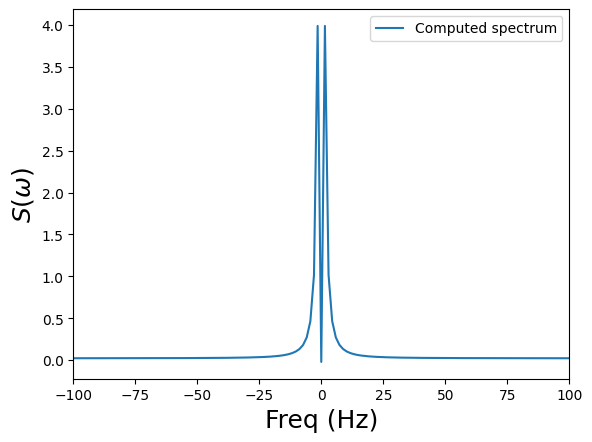

In [27]:
fid_apo = apodize_exp1d(calc_fid-np.mean(calc_fid), 1e-10)
spec_apo = np.real(np.fft.fftshift(np.fft.fft(fid_apo)))
fgrid = np.fft.fftshift(np.fft.fftfreq(Nsteps, np.abs(ren_tgrid[1]-ren_tgrid[0])))


fig, ax = plt.subplots()
ax.plot(fgrid, spec_apo,'-',label='Computed spectrum')
ax.set_xlabel('Freq (Hz)',fontsize=18)
ax.set_xlim([-100,100])
ax.set_ylabel(r'$S(\omega)$',fontsize=18)
ax.legend()
#plt.savefig('../data/eb_deut/coh_only_spect.pdf',dpi=300)


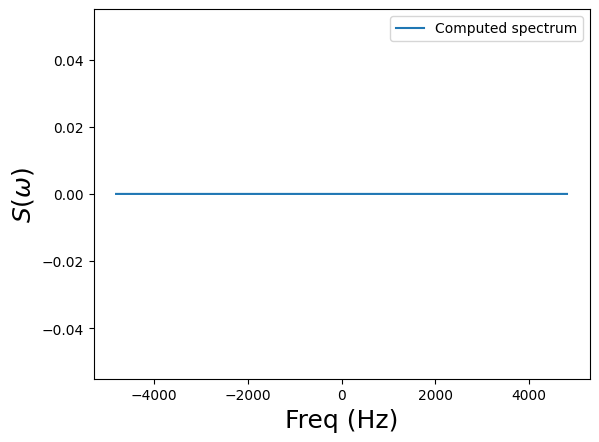

In [28]:
fid_apo = apodize_exp1d(calc_fid_no_relax-np.mean(calc_fid_no_relax), 1e-3)
spec_apo = np.real(np.fft.fftshift(np.fft.fft(fid_apo)))
fgrid = np.fft.fftshift(np.fft.fftfreq(Nsteps, np.abs(ren_tgrid[1]-ren_tgrid[0])))


fig, ax = plt.subplots()
ax.plot(fgrid, spec_apo,'-',label='Computed spectrum')
ax.set_xlabel('Freq (Hz)',fontsize=18)
#ax.set_xlim([-100,100])
ax.set_ylabel(r'$S(\omega)$',fontsize=18)
ax.legend()

In [ ]:
#np.savez('../data/eb_deut/coh_diss_FIDs.npz',cohFID=calc_fid_no_relax,dissFID=calc_fid,tgrid=ren_tgrid)

In [15]:
#####TODO: load the relevant matrices and explore the growth of the Hamming weight distributioj at different time-scales: 

data = np.load('../data/eb_deut/cohMats.npz')

hamm_weights = count_nonzero_tuples(text)

###Initial state in Liouville space...
tar_gammas = np.copy(gyro_rats[mask])
Init_denmat = of.QubitOperator()
sum_gammas =0.0
for i in range(4):
    sum_gammas += tar_gammas[i]
    Init_denmat+=tar_gammas[i]*Sz(i)

Init_denmat = (1.0/sum_gammas)*Init_denmat

Init_denmat_sp = of.get_sparse_operator(Init_denmat,n_qubits=4)


rho0_Liv = np.zeros(len(Normbasis),dtype=complex)


for i in range(len(Normbasis)):
    op = of.get_sparse_operator(Normbasis[i],n_qubits=4)

    rho0_Liv[i] = np.trace(op.toarray().conj().T@Init_denmat_sp.toarray())




In [50]:
H0 = data['H0']
time_step = 1000#(1.0/240)
weights,basis_idxs = get_ham_weights(expm(-1j*H0*time_step)@rho0_Liv,hamm_weights,thresh=1e-10)

In [51]:
weights,basis_idxs

(array([1, 1, 2, 2, 1, 2, 2, 2, 1, 2]),
 [2, 8, 19, 28, 32, 49, 52, 112, 128, 208])

In [55]:
#average of Hamming weight, substracting the 4 dominant 1-Hamming weight terms...
av_paul = []
times = []
for i in range(1000):
    weights,basis_idxs = get_ham_weights(expm(-1j*H0*time_step*i)@rho0_Liv,hamm_weights,thresh=1e-9)

    av_ = np.sum(weights)-4
    av_= av_/len(weights)
    av_paul.append(av_)
    times.append(i)





Text(0, 0.5, 'Av. Pauli weight')

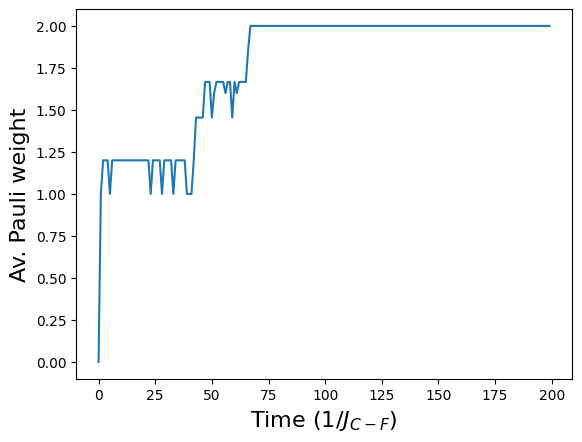

In [54]:
plt.plot(np.array(times),av_paul)
plt.xlabel(r"Time ($1/J_{C-F}$)",fontsize=16)
plt.ylabel("Av. Pauli weight",fontsize=16)

In [41]:
weights, basis_idxs

(array([1, 1, 2, 2, 3, 1, 2, 2, 3, 2, 3, 1, 3, 3, 4, 3, 3, 4, 2, 3]),
 [2,
  8,
  19,
  28,
  30,
  32,
  49,
  52,
  54,
  112,
  114,
  128,
  147,
  156,
  158,
  177,
  180,
  182,
  208,
  210])

In [37]:
weights, basis_idxs

(array([1, 1, 1, 1]), [2, 8, 32, 128])

In [6]:
data.keys()

KeysView(NpzFile '../data/eb_deut/cohMats.npz' with keys: H0, Lx, Ly, FID)

In [28]:
test_coord = np.copy(coords[mask])

name_dict={}
name_dict[0] = 'H_1'
name_dict[1] = '13C'
name_dict[2] = 'F'
name_dict[3] = 'H_2'

for i in range(len(test_coord)):
    for j in range(i+1,len(test_coord)):
        diff = test_coord[i]- test_coord[j]
        d = np.sqrt(np.dot(diff,diff))
        print("Distance between ", name_dict[i], "and ", name_dict[j], "is", d*1e10)
        



Distance between  H_1 and  13C is 3.3549923463197353
Distance between  H_1 and  F is 4.471174904261519
Distance between  H_1 and  H_2 is 4.272797096519679
Distance between  13C and  F is 1.3395232997607769
Distance between  13C and  H_2 is 3.3557506182472796
Distance between  F and  H_2 is 4.469559995799251


In [32]:
test_coord



array([[-8.183280e-11,  2.446250e-10,  3.685370e-11],
       [-2.760806e-10, -2.371720e-11, -1.624990e-11],
       [-3.980537e-10, -5.583010e-11, -6.135590e-11],
       [-5.443000e-13, -1.685899e-10,  1.090588e-10]])

In [31]:
test_zeem = np.copy(zeeman_mats[mask])

for i in range(len(mask)):
    shift = np.trace(1e-6*test_zeem[i])
    print("Dimensionless shift for: ", name_dict[i],"is:", shift)


Dimensionless shift for:  H_1 is: 2.7797199999999992e-05
Dimensionless shift for:  13C is: 0.0005316202
Dimensionless shift for:  F is: -0.0002988562
Dimensionless shift for:  H_2 is: 2.8057599999999994e-05


In [11]:
Rel_sup_op = get_isotropic_R(2*np.pi*iso_zeeman.toarray(),glob_Qpq,tc,Normbasis)

Finsihed: 10 %
Finsihed: 20 %
Finsihed: 30 %
Finsihed: 40 %
Finsihed: 50 %
Finsihed: 60 %
Finsihed: 70 %
Finsihed: 80 %
Finsihed: 90 %
Finsihed: 100 %


In [7]:
#protocol
data_FID = np.load('../data/1D_13C_traces/time_data.npy')
tgrid = data_FID[:,0]


H0_Liv = singcomm_supOp(2*np.pi*iso_zeeman.toarray(),Normbasis,nqubs=4)


Lx = Sx(1) ####For 13C
Ly = Sy(1)
#for i in range(4):
#    Lx+=Sx(i)



In [8]:
Lx_sp = of.get_sparse_operator(Lx,n_qubits=4)
Ly_sp = of.get_sparse_operator(Ly,n_qubits=4)

Lx_liv = singcomm_supOp(Lx_sp.toarray(),Normbasis,nqubs=4)
Ly_liv = singcomm_supOp(Ly_sp.toarray(),Normbasis,nqubs=4)

In [9]:
###Generation of the initial state
tar_gammas = np.copy(gyro_rats[mask])
Init_denmat = of.QubitOperator()
sum_gammas =0.0
for i in range(4):
    sum_gammas += tar_gammas[i]
    Init_denmat+=tar_gammas[i]*Sz(i)

Init_denmat = (1.0/sum_gammas)*Init_denmat

Init_denmat_sp = of.get_sparse_operator(Init_denmat,n_qubits=4)

###Target observable to get FID...

tar_obs = Sx(1)+1j*Sy(1) #for 13C detection
tar_obs_2 = Sz(1)

tar_obs_sp = of.get_sparse_operator(tar_obs,n_qubits=4)
tar_obs_sp_2 = of.get_sparse_operator(tar_obs_2,n_qubits=4)


rho0_Liv = np.zeros(len(Normbasis),dtype=complex)
tar_obs_Liv = np.zeros(len(Normbasis),dtype=complex)
tar_obs_Liv2 = np.zeros(len(Normbasis),dtype=complex)

for i in range(len(Normbasis)):
    op = of.get_sparse_operator(Normbasis[i],n_qubits=4)

    rho0_Liv[i] = np.trace(op.toarray().conj().T@Init_denmat_sp.toarray())
    tar_obs_Liv[i] = np.trace(op.toarray().conj().T@tar_obs_sp.toarray())
    tar_obs_Liv2[i] = np.trace(op.toarray().conj().T@tar_obs_sp_2.toarray())



In [10]:
###Time propagation:
rotX_op = expm(-1j*Lx_liv*np.pi/2)

rot_rho = rotX_op@rho0_Liv


###reducing the number of points in the time grid, keeping spectral resolution...
nstep = 5
Nsteps = len(tgrid)//nstep
ren_tgrid = np.zeros(Nsteps)

for i in range(Nsteps):
    ren_tgrid[i] = tgrid[nstep*i]


calc_fid = np.zeros(len(ren_tgrid),dtype=complex)
for i in range(len(ren_tgrid)):
    #prop_t = expm(-1j*(H0_Liv-Rel_sup_op)*ren_tgrid[i])
    prop_t = expm(-1j*(H0_Liv)*ren_tgrid[i])
    #calc_fid[i] = np.vdot(tar_obs_Liv,prop_t@rot_rho)
    calc_fid[i] = np.vdot(tar_obs_Liv2,rotX_op.conj().T@prop_t@rot_rho)




/var/folders/rm/xdxcjr7n7_13f9m1905zyf6c0000gq/T/ipykernel_17867/3065886598.py:13: ComplexWarning: Casting complex values to real discards the imaginary part
  ren_tgrid[i] = tgrid[nstep*i]


In [ ]:
#np.savez('../data/eb_deut/cohMats.npz',H0=H0_Liv,Lx=Lx_liv,Ly=Ly_liv,FID=calc_fid)

In [ ]:
#data = np.load('../data/eb_deut/cohMats.npz')

In [ ]:
#data['H0']

array([[ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j, -5.02946416e+09+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       ...,
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  5.99878774e+09+0.j,  0.00000000e+00+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  1.10282519e+10+0.j,
         0.00000000e+00+0.j],
       [ 0.00000000e+00+0.j,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
        ...,  0.00000000e+00+0.j,  0.00000000e+00+0.j,
         1.60577161e+10+0.j]], shape=(256, 256))

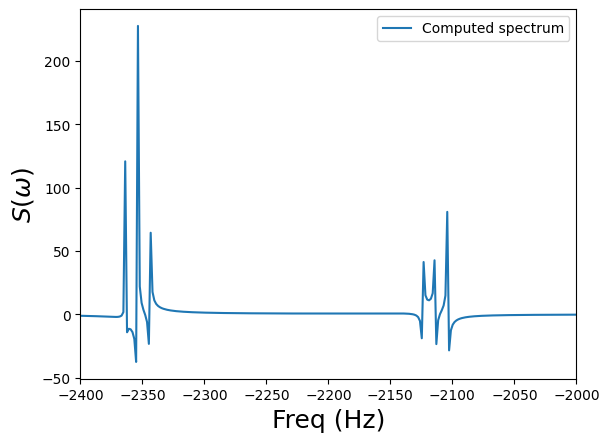

In [20]:
fid_apo = apodize_exp1d(calc_fid-np.mean(calc_fid), 1e-10)
spec_apo = np.real(np.fft.fftshift(np.fft.fft(fid_apo)))
fgrid = np.fft.fftshift(np.fft.fftfreq(Nsteps, np.abs(ren_tgrid[1]-ren_tgrid[0])))


fig, ax = plt.subplots()
ax.plot(fgrid, spec_apo,'-',label='Computed spectrum')
ax.set_xlabel('Freq (Hz)',fontsize=18)
ax.set_xlim([-2400,-2000])
ax.set_ylabel(r'$S(\omega)$',fontsize=18)
ax.legend()
plt.savefig('../data/eb_deut/coh_only_spect.pdf',dpi=300)


In [71]:
####TO DEBUG what we are getting... lets consider a crude approximation to the computation...

###Initial state:
psi0 = np.zeros(2**4,dtype=complex)

psi0[0]=1.0
psi0[2]=1j

psi0 = (1.0/np.sqrt(2))*psi0


eigvals,eigvects = np.linalg.eigh(iso_zeeman.toarray())

weights = []
for i in range(2**4):
    weights.append(np.abs(np.vdot(psi0,eigvects[:,i]))**2)



In [112]:
######Performing a reference calculation....
Init_rho = of.QubitOperator()
tot_gams = 0.0

for i in range(len(tar_gammas)):
    tot_gams+=tar_gammas[i]
    Init_rho+=tar_gammas[i]*Sz(i)


Init_rho = (1.0/tot_gams)*Init_rho
Init_rho = of.get_sparse_operator(Init_rho)

Unit_rot = expm(1j*of.get_sparse_operator(Lx,n_qubits=4).toarray()*np.pi/2)


Rot_init = Unit_rot.conj().T@Init_rho@Unit_rot

nstep = 5
Nsteps = len(tgrid)//nstep
ren_tgrid = np.zeros(Nsteps)

for i in range(Nsteps):
    ren_tgrid[i] = tgrid[nstep*i]


calc_fid = np.zeros(len(ren_tgrid),dtype=complex)
for i in range(len(ren_tgrid)):
    #prop_t = expm(-1j*(H0_Liv-Rel_sup_op)*ren_tgrid[i])
    prop_t = expm(1j*2*np.pi*(iso_zeeman.toarray())*ren_tgrid[i])
    rho_t = prop_t.conj().T@Rot_init@prop_t

    rho_t_origbasis = Unit_rot@rho_t@Unit_rot.conj().T

    #calc_fid[i] = np.trace((tar_obs_sp)@rho_t)
    calc_fid[i] = np.trace(Init_rho@rho_t_origbasis)








/var/folders/rm/xdxcjr7n7_13f9m1905zyf6c0000gq/T/ipykernel_74752/4222017375.py:23: ComplexWarning: Casting complex values to real discards the imaginary part
  ren_tgrid[i] = tgrid[nstep*i]


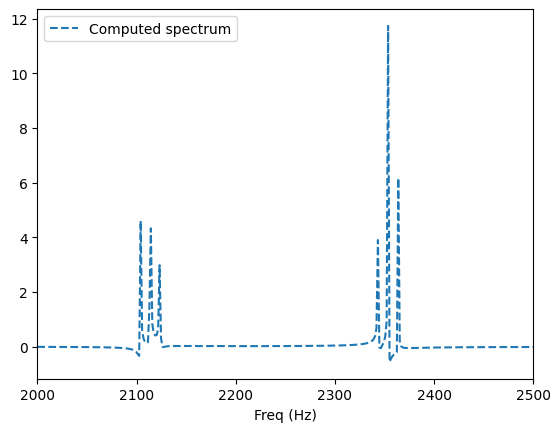

In [118]:
fid_apo = apodize_exp1d(calc_fid-np.mean(calc_fid), 1)
spec_apo = np.real(np.fft.fftshift(np.fft.fft(fid_apo)))
fgrid = np.fft.fftshift(np.fft.fftfreq(Nsteps, np.abs(ren_tgrid[1]-ren_tgrid[0])))


fig, ax = plt.subplots()
ax.plot(fgrid, spec_apo,'--',label='Computed spectrum')
ax.set_xlabel('Freq (Hz)')
ax.set_xlim([2000,2500])
#ax.set_xlim([-2500,-2000])

ax.legend()


In [ ]:
###TODO: double check that the Liouville calculation was done correctly. If that is the case, there is something wrong going on with space truncation

(np.float64(0.4999999999999999), np.float64(0.49999999999997635))

In [70]:
eigvects[:,0]

array([1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
       0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j])

In [60]:
eigvals

array([-1.27783238e+09, -1.07647898e+09, -5.24449238e+08, -4.77368370e+08,
       -4.77368301e+08, -3.23095597e+08, -2.76014960e+08, -2.76014890e+08,
        2.76014770e+08,  2.76014840e+08,  3.23095707e+08,  4.77368421e+08,
        4.77368490e+08,  5.24449128e+08,  1.07647885e+09,  1.27783251e+09])

In [ ]:
array([ 4.77368421e+08+1.32348898e-23j,  1.07647885e+09-1.65436123e-24j,
        5.24449128e+08-7.04732883e-53j,  4.77368490e+08+0.00000000e+00j,
       -1.07647898e+09-1.65078506e-20j, -5.24449238e+08+4.97171424e-23j,
       -3.23095597e+08-6.61741664e-24j, -2.76014890e+08-2.56683754e-24j,
        3.23095707e+08+5.23355396e-23j,  2.76014840e+08-2.43053271e-20j,
        2.76014770e+08-9.65073348e-25j, -4.77368301e+08+0.00000000e+00j,
       -4.77368370e+08+0.00000000e+00j, -2.76014960e+08+0.00000000e+00j,
       -1.27783238e+09+0.00000000e+00j,  1.27783251e+09+0.00000000e+00j])


In [59]:
eigvals[0]-eigvals[1]

np.float64(-201353400.41922402)

In [52]:
test = np.zeros(2**4)

test[0] = 1.0

np.vdot(test,iso_zeeman.toarray()@test)

np.complex128(-1277832378.1591275+0j)

In [49]:
eigvals[15]-eigvals[14]

np.float64(201353660.41922402)

In [45]:
weights[15],weights[14]

(np.float64(0.4999999999999999), np.float64(0.499999999999976))

In [40]:
np.argsort(weights)

array([ 0,  1,  4,  2,  3,  9,  7,  8,  5, 10,  6, 11, 12, 13, 14, 15])

/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


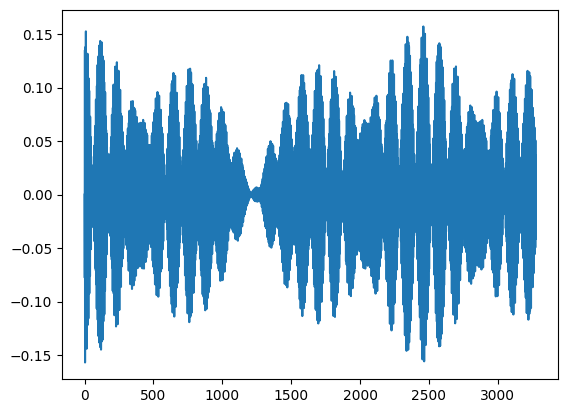

In [79]:
plt.plot(calc_fid)

/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


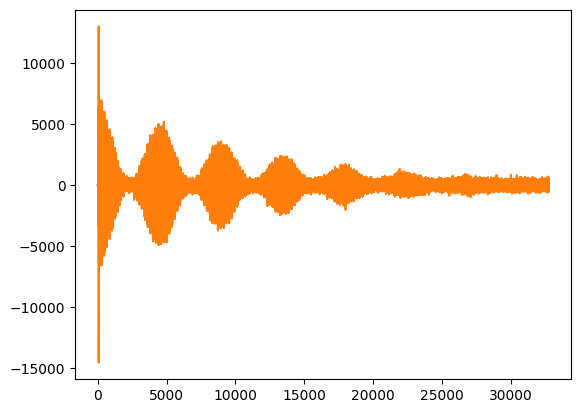

In [75]:
plt.plot(data_FID)

# Reference data

In [9]:
freqs = np.load('../data/1D_13C_traces/freq_data.npy')
time = np.load('../data/1D_13C_traces/time_data.npy')

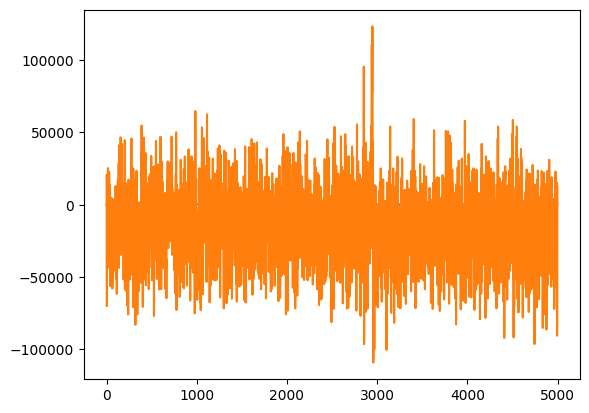

In [18]:
plt.plot(freqs[10000:15000])

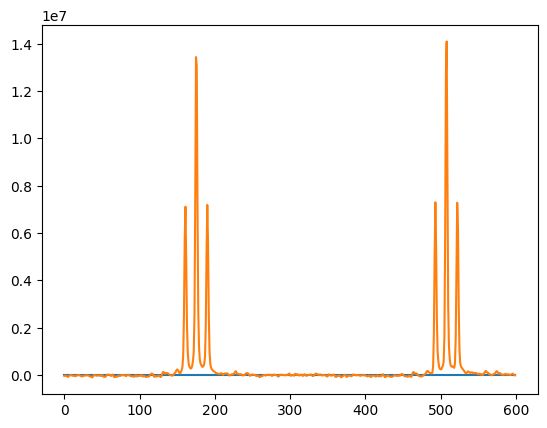

In [16]:
plt.plot(freqs[15400:16000])

/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/luismartinezmartinez/pyenvs/qiskit_backends/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


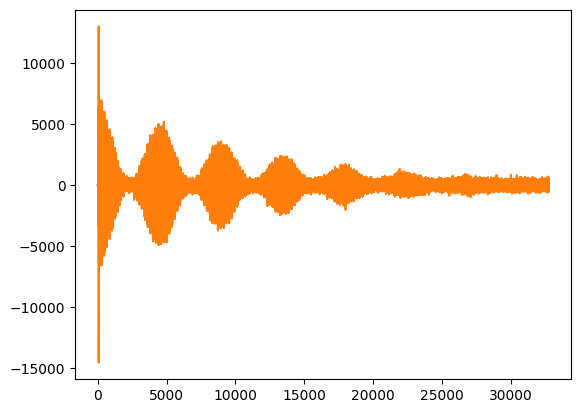

In [11]:
plt.plot(time)